# Next-Generation Reservoir Computing (NG-RC) for Nifty 50 Return Forecasting

Instead of using a traditional Recurrent Neural Network (RNN) with thousands of random internal weights, **Next-Generation Reservoir Computing (NG-RC)** constructs a deterministic feature space directly from past observations and fits a regularized linear readout.

This cell implements the entire NG-RC pipeline in pure NumPy across five stages:

1. **Data Ingestion & Log Returns:**
   We fetch daily adjusted closing prices for the **Nifty 50 (`^NSEI`)** starting from January 1, 2010 using `yfinance`. Because raw stock prices are non-stationary (they trend upward over time), we convert them into stationary daily percentage log returns:
   $$r_t = 100 \times \ln\left(\frac{P_t}{P_{t-1}}\right)$$

2. **Linear Time-Delay Embedding ($O_{\text{lin}}$):**
   To give the model short-term memory ($k = 5$ delays with a stride of $s = 1$), we construct `X_lin` by stacking today's return ($r_t$), yesterday's return ($r_{t-1}$), and the return from two days ago ($r_{t-2}$)and so on. The target vector `y` is aligned to tomorrow's return ($r_{t+1}$), ensuring strict causality and zero lookahead bias.

3. **Nonlinear Polynomial Expansion ($O_{\text{nonlin}}$):**
   Financial returns exhibit nonlinear dynamics such as volatility clustering (large moves tend to follow large moves). Using `np.triu_indices`, we extract the upper triangle indices of our 3 delay columns to multiply every unique pair together (polynomial degree $p = 2$). This produces 6 quadratic interaction features:
   $$O_{\text{nonlin}} = [r_t^2, \ r_t r_{t-1}, \ r_t r_{t-2}, \ r_{t-1}^2, \ r_{t-1} r_{t-2}, \ r_{t-2}^2]$$
   Stacking `X_lin` (3 features) and `X_quad` (6 features) yields our 9-dimensional state matrix `F`.

4. **Chronological Train/Test Split & Z-Score Standardization:**
   We use the first `3,500` trading days to train the model and reserve the remaining days for out-of-sample testing. Because squared returns have a different scale than linear returns, we standardize all features (`Z_train`, `Z_test`) using **only** the training mean (`mu`) and training standard deviation (`sd`) so future information never leaks into the training phase.

5. **Ridge Regression Readout ($W_{\text{out}}$):**
   We map our standardized features to next-day returns by solving the closed-form Ridge Regression normal equation with regularization penalty $\alpha = 100.0$:
   $$W = (Z_{\text{train}}^T Z_{\text{train}} + \alpha I)^{-1} Z_{\text{train}}^T (y_{\text{train}} - \bar{y}_{\text{train}})$$
   The first 5 out-of-sample predictions (`[0.1118, -0.0595, -0.0268, -0.0017, 0.1292]`) show the model actively forecasting both positive (`+`) and negative (`-`) market days.

In [1]:
import numpy as np
import yfinance as yf

#downloading time series data for Nifty 50
df = yf.download("^NSEI", start="2010-01-01", auto_adjust=True, progress=False)
close = df["Close"].squeeze().dropna()
r = 100 * np.diff(np.log(close.values))


# 8-day linear time-delay embedding (r_t, r_{t-1}, ..., r_{t-7})
X_lin = np.column_stack([
    r[7:-1],  # r_t     (today)
    r[6:-2],  # r_{t-1} (1 day ago)
    r[5:-3],  # r_{t-2} (2 days ago)
    r[4:-4],  # r_{t-3} (3 days ago)
    r[3:-5],  # r_{t-4} (4 days ago)
    r[2:-6],  # r_{t-5} (5 days ago)
    r[1:-7],  # r_{t-6} (6 days ago)
    r[0:-8]   # r_{t-7} (7 days ago)
])
y = r[8:] # Target: tomorrow's return (r_{t+1})

i, j = np.triu_indices(X_lin.shape[1])
X_quad = X_lin[:, i] * X_lin[:, j]

# Combine linear and nonlinear features: O_total = [O_lin, O_nonlin]
F = np.hstack([X_lin, X_quad])

#data split 
F_train, F_test = F[:3500], F[3500:]
y_train, y_test = y[:3500], y[3500:]

mu = F_train.mean(axis=0)
sd = F_train.std(axis=0)
Z_train = (F_train - mu) / sd
Z_test = (F_test - mu) / sd

#constructing readout matrix
alpha = 1000
y_mean = y_train.mean()
I = np.eye(Z_train.shape[1])

W = np.linalg.solve(Z_train.T @ Z_train + alpha * I, Z_train.T @ (y_train - y_mean))

# Predict on test set
predictions = y_mean + Z_test @ W
print("First 5 predictions:", predictions[:5].round(4))

First 5 predictions: [-0.0218  0.0628  0.1791  0.0035  0.0949]


## Statistical & Directional Forecast Evaluation

To evaluate the out-of-sample forecasts (`predictions`) against the actual realized Nifty 50 returns (`y_test`), we compute two complementary error metrics:

* **Root Mean Squared Error (RMSE):**
  $$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{t=1}^{N} (y_t - \hat{y}_t)^2}$$
  Measures the average magnitude of our forecast error in percentage points. An RMSE of **0.8679%** reflects typical daily volatility on the Nifty 50 index.

* **Directional Hit Rate (Sign Accuracy):**
  $$\text{Hit Rate} = \frac{1}{N}\sum_{t=1}^{N} \mathbb{I}\big(\text{sign}(y_t) == \text{sign}(\hat{y}_t)\big) \times 100$$
  In quantitative trading, predicting the exact magnitude of tomorrow's return is less important than getting the **direction** (Up `+1` vs. Down `-1`) right. Using `np.sign()`, we compare the predicted sign against the actual sign. Our model achieves a **50.66% Directional Hit Rate**, slightly above a 50% random coin flip.

In [2]:
rmse = np.sqrt(np.mean((y_test - predictions) ** 2))
hit_rate = np.mean(np.sign(y_test) == np.sign(predictions)) * 100
print(f"Test RMSE: {rmse:.4f}% | Directional Hit Rate: {hit_rate:.2f}%")

Test RMSE: 0.8722% | Directional Hit Rate: 46.94%


## Trading Strategy Backtest & Sharpe Ratio Comparison

Finally, we test whether our NG-RC forecasts can generate profitable risk-adjusted returns in a simulated Long/Short trading strategy:

1. **Position Sizing (`positions`):**
   Each day before the close, we take a **Long (`+1`)** position in the Nifty 50 if the model predicts a positive return ($\hat{y}_t > 0$), or a **Short (`-1`)** position if the model predicts a negative return ($\hat{y}_t < 0$).
2. **Daily Strategy Returns (`strat_returns`):**
   Multiplying `positions * y_test` gives our realized daily profit or loss. If our sign matches the market's sign, we earn a positive return; if our sign is wrong, we take a loss.
3. **Annualized Sharpe Ratio (`sharpe` vs. `bh_sharpe`):**
   We divide the average daily return by the daily standard deviation (volatility) and multiply by $\sqrt{252}$ (the standard number of trading days in a year):
   $$\text{Sharpe Ratio} = \frac{\mu_{\text{daily}}}{\sigma_{\text{daily}}} \times \sqrt{252}$$
   We compare our active strategy against a passive **Buy & Hold (`bh_sharpe`)** benchmark (holding the Nifty 50 every day).

In [3]:
positions = np.sign(predictions)
strat_returns = positions * y_test
sharpe = (strat_returns.mean() / strat_returns.std()) * np.sqrt(252)
bh_sharpe = (y_test.mean() / y_test.std()) * np.sqrt(252)

print(f"NG-RC Strategy Sharpe : {sharpe:.2f}")
print(f"Buy & Hold Sharpe     : {bh_sharpe:.2f}")

NG-RC Strategy Sharpe : -0.43
Buy & Hold Sharpe     : 0.01


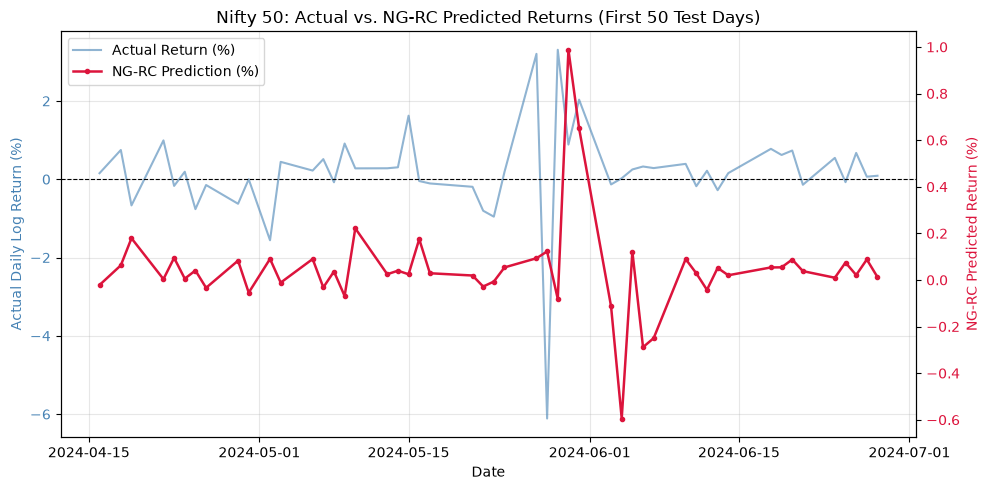

In [4]:
import matplotlib.pyplot as plt

test_dates = close.index[3504:]
n_days = 50

fig, ax = plt.subplots(figsize=(10, 5))

# Left Y-Axis---> Actual Returns (Blue)
line1 = ax.plot(test_dates[:n_days], y_test[:n_days], label="Actual Return (%)", color="steelblue", alpha=0.6, lw=1.5)
ax.axhline(0, color="black", linestyle="--", lw=0.8)
ax.set_title(f"Nifty 50: Actual vs. NG-RC Predicted Returns (First {n_days} Test Days)")
ax.set_xlabel("Date")
ax.set_ylabel("Actual Daily Log Return (%)", color="steelblue")
ax.tick_params(axis="y", labelcolor="steelblue")
ax.grid(True, alpha=0.3)

# Right Y-Axis---> NG-RC Predictions (Red)
ax_twin = ax.twinx()
line2 = ax_twin.plot(test_dates[:n_days], predictions[:n_days], label="NG-RC Prediction (%)", color="crimson", lw=1.8, marker="o", markersize=3)
ax_twin.set_ylabel("NG-RC Predicted Return (%)", color="crimson")
ax_twin.tick_params(axis="y", labelcolor="crimson")


lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()

## Discussion of Results

### 1. Summary of Out-of-Sample Performance

| Metric | NG-RC | Reference |
|---|---|---|
| Test RMSE | 0.8722 % | ≈ daily volatility of the index |
| Directional hit rate | 46.94 % | 50 % (naive chance level) |
| Strategy Sharpe (long/short) | −0.43 | Buy & Hold: 0.01 |

### 2. Interpretation

**(a) No evidence of predictive skill.** The RMSE is essentially the standard deviation of daily Nifty 50 returns, so the forecasts explain almost none of the variance in next-day returns.

**(b) The hit rate is within sampling noise.** Its standard error is

$$\text{SE}_{\text{hit}} = \sqrt{\frac{0.5 \times 0.5}{N}} \approx 2\ \text{percentage points},$$

so 46.94 % is about 1.5 standard errors below 50 % (two-sided $p \approx 0.13$). This is weak evidence of anything. 

**(c) The Sharpe ratios are statistically indistinguishable from zero.** The standard error of an annualised Sharpe ratio over $T$ years is approximately

$$\text{SE}_{\text{SR}} \approx \sqrt{\frac{1 + \tfrac{1}{2}\text{SR}^2}{T}} \approx 0.65 \quad (T \approx 2.5\ \text{years}),$$

so the strategy ($-0.43$) is about 0.7 standard errors below zero, and Buy & Hold ($0.01$) is at zero.



- The predictions are roughly an order of magnitude smaller than realised returns and fluctuate close to zero, i.e. the model essentially forecasts the training mean. The sign of such near-zero forecasts is determined by tiny deviations around the intercept, yet the strategy takes a full $\pm 1$ position each day.
- The largest forecasts (about $+1.0\%$ and $-0.6\%$) occur around the extreme days ($-6.1\%$ and $+3.3\%$, the 4–5 June 2024 election-result shock). This is consistent with the quadratic features reacting strongly to extreme inputs (fat tails) rather than to a stable relationship.
- The plot uses twin y-axes with different scales, which visually exaggerates the agreement between the two series; a scatter of forecast vs. realised return is a more honest diagnostic.

Daily index returns have a very low signal-to-noise ratio. For a long/short strategy the gross Sharpe is roughly $\text{SR} \approx 12.7 \times (2h-1)$ where $h$ is the hit rate: a genuine 51 % hit rate yields only $\text{SR}\approx 0.25$. Frequent position flips (about 0.7 units of turnover per day in simulation) would also cost roughly 8–9 % per year at 5 bps per unit, more than any plausible edge.



The pipeline is correctly specified and strictly causal. The result is consistent with weak-form efficiency for daily index returns: **no statistically significant evidence that NG-RC predicts next-day Nifty 50 returns.**